🎯 NEURAL NETWORK DEMONSTRATION: XOR PROBLEM
📊 TRAINING DATA:
Input (X) | Output (y)
--------------------
  [0 0]   |    0
  [0 1]   |    1
  [1 0]   |    1
  [1 1]   |    0
🧠 Neural Network Initialized!
   Input Layer: 2 neurons
   Hidden Layer: 3 neurons
   Output Layer: 1 neuron
   Learning Rate: 0.1

📚 DETAILED TRAINING PROCESS (First 3 epochs)

🚀 TRAINING FOR 3 EPOCHS

EPOCH 0: Loss = 0.267582
Predictions: [0.61521647 0.64757458 0.62071863 0.65098344]
Actual:      [0 1 1 0]
------------------------------

EPOCH 1: Loss = 0.267214
Predictions: [0.61385822 0.6461958  0.61930528 0.64955847]
Actual:      [0 1 1 0]
------------------------------

EPOCH 2: Loss = 0.266851
Predictions: [0.61251052 0.64482712 0.61790282 0.64814385]
Actual:      [0 1 1 0]
------------------------------

⏭️  Training continues silently for 200 more epochs...

🎉 FINAL RESULTS
Input | Target | Prediction | Error
----------------------------------------
[0 0] |   0    |   0.4855   | 0.4855
[0 1] |   1    |   0.

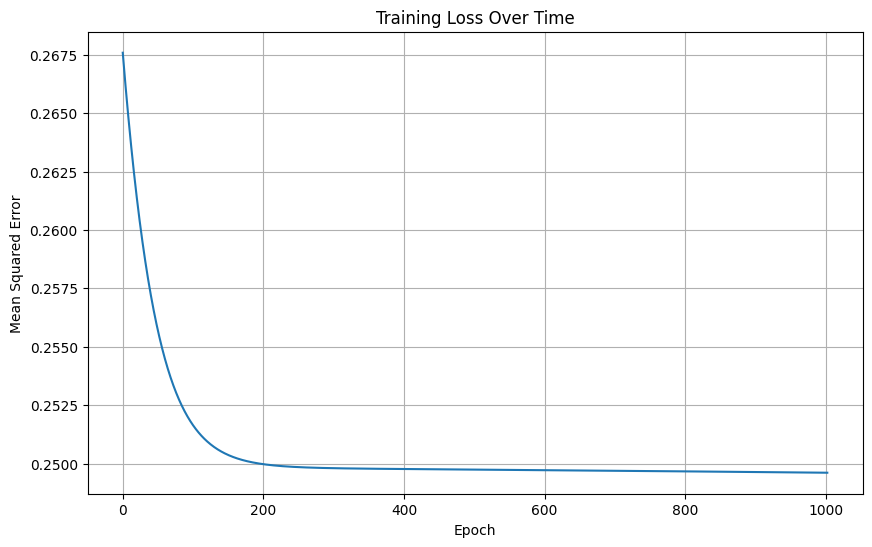


🎓 KEY CONCEPTS EXPLAINED:

🔄 FORWARD PROPAGATION:
   1. Input data flows through the network
   2. Each layer: output = activation(weights × input + bias)
   3. Final layer produces prediction

🔙 BACKWARD PROPAGATION:
   1. Calculate error between prediction and target
   2. Compute gradients (how much each weight contributed to error)
   3. Update weights to reduce error (gradient descent)
   4. Propagate error backward through all layers

🧮 MATHEMATICS:
   • Activation: sigmoid(x) = 1/(1 + e^(-x))
   • Loss: MSE = mean((predicted - actual)²)
   • Gradient: ∂Loss/∂weight (partial derivative)
   • Update: weight = weight - learning_rate × gradient

🎯 XOR PROBLEM:
   • Classic test for neural networks
   • Cannot be solved by single perceptron (not linearly separable)
   • Requires hidden layer to create non-linear decision boundary



In [4]:
import numpy as np
import matplotlib.pyplot as plt

class SimpleNeuralNetwork:
    """
    A simple 3-layer neural network (input -> hidden -> output)
    Perfect for understanding forward and backward propagation
    """
    
    def __init__(self, input_size=2, hidden_size=3, output_size=1):
        # Initialize weights randomly (small values)
        np.random.seed(42)  # For reproducible results
        
        # Weights from input to hidden layer
        self.W1 = np.random.randn(input_size, hidden_size) * 0.5
        self.b1 = np.zeros((1, hidden_size))  # Hidden layer bias
        
        # Weights from hidden to output layer
        self.W2 = np.random.randn(hidden_size, output_size) * 0.5
        self.b2 = np.zeros((1, output_size))  # Output layer bias
        
        # Learning rate
        self.learning_rate = 0.1
        
        print("🧠 Neural Network Initialized!")
        print(f"   Input Layer: {input_size} neurons")
        print(f"   Hidden Layer: {hidden_size} neurons") 
        print(f"   Output Layer: {output_size} neuron")
        print(f"   Learning Rate: {self.learning_rate}")
    
    def sigmoid(self, x):
        """Activation function: sigmoid"""
        # Clip to prevent overflow
        x = np.clip(x, -250, 250)
        return 1 / (1 + np.exp(-x))
    
    def sigmoid_derivative(self, x):
        """Derivative of sigmoid function"""
        return x * (1 - x)
    
    def forward_propagation(self, X):
        """
        🔄 FORWARD PROPAGATION STEP
        Data flows from input → hidden → output
        """
        # print("\n--- FORWARD PROPAGATION ---")
        
        # Step 1: Input to Hidden Layer
        # print(f"1. Input: {X}")
        
        # Linear transformation: z1 = X * W1 + b1
        self.z1 = np.dot(X, self.W1) + self.b1
        # print(f"2. Hidden layer (before activation): {self.z1}")
        
        # Apply activation function: a1 = sigmoid(z1)
        self.a1 = self.sigmoid(self.z1)
        # print(f"3. Hidden layer (after sigmoid): {self.a1}")
        
        # Step 2: Hidden to Output Layer
        # Linear transformation: z2 = a1 * W2 + b2
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        # print(f"4. Output layer (before activation): {self.z2}")
        
        # Apply activation function: a2 = sigmoid(z2)
        self.a2 = self.sigmoid(self.z2)
        # print(f"5. Final output (prediction): {self.a2}")
        
        return self.a2
    
    def compute_loss(self, y_true, y_pred):
        """Calculate Mean Squared Error loss"""
        loss = np.mean((y_true - y_pred) ** 2)
        return loss
    
    def backward_propagation(self, X, y_true):
        """
        🔙 BACKWARD PROPAGATION STEP
        Calculate gradients and update weights
        """
        # print("\n--- BACKWARD PROPAGATION ---")
        
        # Number of samples
        m = X.shape[0]
        
        # Step 1: Calculate output layer error
        # Error = predicted - actual
        output_error = self.a2 - y_true
        # print(f"1. Output error: {output_error}")
        
        # Step 2: Calculate gradients for output layer
        # δ2 = error * sigmoid_derivative(a2)
        delta2 = output_error * self.sigmoid_derivative(self.a2)
        # print(f"2. Output layer delta: {delta2}")
        
        # Gradients for W2 and b2
        dW2 = np.dot(self.a1.T, delta2) / m
        db2 = np.sum(delta2, axis=0, keepdims=True) / m
        # print(f"3. Gradients for W2: {dW2}")
        # print(f"4. Gradients for b2: {db2}")
        
        # Step 3: Calculate hidden layer error (backpropagate)
        # Hidden error = δ2 * W2^T * sigmoid_derivative(a1)
        hidden_error = np.dot(delta2, self.W2.T)
        delta1 = hidden_error * self.sigmoid_derivative(self.a1)
        # print(f"5. Hidden layer delta: {delta1}")
        
        # Gradients for W1 and b1
        dW1 = np.dot(X.T, delta1) / m
        db1 = np.sum(delta1, axis=0, keepdims=True) / m
        # print(f"6. Gradients for W1: {dW1}")
        # print(f"7. Gradients for b1: {db1}")
        
        # Step 4: Update weights (Gradient Descent)
        # print("\n--- WEIGHT UPDATES ---")
        # print(f"Before - W2: {self.W2.flatten()}")
        self.W2 -= self.learning_rate * dW2
        self.b2 -= self.learning_rate * db2
        self.W1 -= self.learning_rate * dW1
        self.b1 -= self.learning_rate * db1
        # print(f"After  - W2: {self.W2.flatten()}")
    
    def train(self, X, y, epochs=100):
        """Train the neural network"""
        losses = []
        
        print(f"\n🚀 TRAINING FOR {epochs} EPOCHS")
        print("="*50)
        
        for epoch in range(epochs):
            # Forward propagation
            predictions = self.forward_propagation(X)
            
            # Calculate loss
            loss = self.compute_loss(y, predictions)
            losses.append(loss)
            
            # Backward propagation
            self.backward_propagation(X, y)
            
            # Print progress
            if epoch % 20 == 0 or epoch < 3:
                print(f"\nEPOCH {epoch}: Loss = {loss:.6f}")
                print(f"Predictions: {predictions.flatten()}")
                print(f"Actual:      {y.flatten()}")
                if epoch < 3:
                    print("-" * 30)
        
        return losses
    
    def predict(self, X):
        """Make predictions on new data"""
        return self.forward_propagation(X)

# 🎯 DEMONSTRATION: XOR Problem
print("=" * 60)
print("🎯 NEURAL NETWORK DEMONSTRATION: XOR PROBLEM")
print("=" * 60)

# Create XOR dataset
# XOR: (0,0)→0, (0,1)→1, (1,0)→1, (1,1)→0
X = np.array([[0, 0],
              [0, 1], 
              [1, 0],
              [1, 1]])

y = np.array([[0],
              [1],
              [1], 
              [0]])

print("📊 TRAINING DATA:")
print("Input (X) | Output (y)")
print("-" * 20)
for i in range(len(X)):
    print(f"  {X[i]}   |    {y[i][0]}")

# Create and train neural network
nn = SimpleNeuralNetwork(input_size=2, hidden_size=3, output_size=1)

# Train for just 3 epochs to see the process clearly
print("\n" + "="*60)
print("📚 DETAILED TRAINING PROCESS (First 3 epochs)")
print("="*60)

losses = nn.train(X, y, epochs=3)

# Continue training silently for better results
print("\n⏭️  Training continues silently for 200 more epochs...")
additional_losses = []
for epoch in range(1000):
    predictions = nn.forward_propagation(X)
    loss = nn.compute_loss(y, predictions)
    additional_losses.append(loss)
    nn.backward_propagation(X, y)

all_losses = losses + additional_losses

# Final results
print("\n" + "="*60)
print("🎉 FINAL RESULTS")
print("="*60)

final_predictions = nn.predict(X)
print("Input | Target | Prediction | Error")
print("-" * 40)
for i in range(len(X)):
    error = abs(y[i][0] - final_predictions[i][0])
    print(f"{X[i]} |   {y[i][0]}    |   {final_predictions[i][0]:.4f}   | {error:.4f}")

print(f"\nFinal Loss: {all_losses[-1]:.6f}")

# Plot training progress
plt.figure(figsize=(10, 6))
plt.plot(all_losses)
plt.title('Training Loss Over Time')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.grid(True)
plt.show()

print("\n" + "="*60)
print("🎓 KEY CONCEPTS EXPLAINED:")
print("="*60)
print("""
🔄 FORWARD PROPAGATION:
   1. Input data flows through the network
   2. Each layer: output = activation(weights × input + bias)
   3. Final layer produces prediction

🔙 BACKWARD PROPAGATION:
   1. Calculate error between prediction and target
   2. Compute gradients (how much each weight contributed to error)
   3. Update weights to reduce error (gradient descent)
   4. Propagate error backward through all layers

🧮 MATHEMATICS:
   • Activation: sigmoid(x) = 1/(1 + e^(-x))
   • Loss: MSE = mean((predicted - actual)²)
   • Gradient: ∂Loss/∂weight (partial derivative)
   • Update: weight = weight - learning_rate × gradient

🎯 XOR PROBLEM:
   • Classic test for neural networks
   • Cannot be solved by single perceptron (not linearly separable)
   • Requires hidden layer to create non-linear decision boundary
""")

🔍 COMPARAÇÃO: NEURAL NETWORK NORMAL vs NEURAL HAWKES PROCESS

📊 PRINCIPAIS DIFERENÇAS:

1️⃣ TIPO DE DADOS DE ENTRADA:
------------------------------
🔵 NN NORMAL:
   Entrada: Matrix estática (3, 3)
   Exemplo: [0.5 0.3 0.8]
   ➤ Features independentes e fixas

🔴 NN HAWKES:
   Entrada: Sequência temporal [0.5 1.2 1.8 3.1 3.3 5.2 7.8]
   ➤ Cada entrada depende do HISTÓRICO de eventos
   ➤ Ordem temporal é CRUCIAL

2️⃣ FUNÇÃO OBJETIVO (LOSS):
------------------------------
🔵 NN NORMAL:
   Loss = MSE = (y_pred - y_true)²
   ➤ Comparação direta entre predição e target

🔴 NN HAWKES:
   Loss = -Log-Likelihood = -Σlog(λ(tᵢ)) + ∫λ(t)dt
   ➤ Modelar PROBABILIDADE de eventos
   ➤ Duas componentes: eventos observados + integral

3️⃣ ARQUITETURA DA REDE:
------------------------------
🔵 NN NORMAL:
   Input → Hidden → Output
   ➤ Mapeamento direto entrada → saída
   ➤ Sem memória temporal

🔴 NN HAWKES:
   Events → Temporal_Features → Hidden → Intensity
   ➤ Processamento temporal primeiro
   ➤ Output

/var/folders/d1/5ns84m_57hb0y1gpr6jmwg900000gn/T/ipykernel_90595/2450438055.py:246: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/d1/5ns84m_57hb0y1gpr6jmwg900000gn/T/ipykernel_90595/2450438055.py:246: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/hugoramossoares/Sites/ebgeniusai/myenv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/hugoramossoares/Sites/ebgeniusai/myenv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


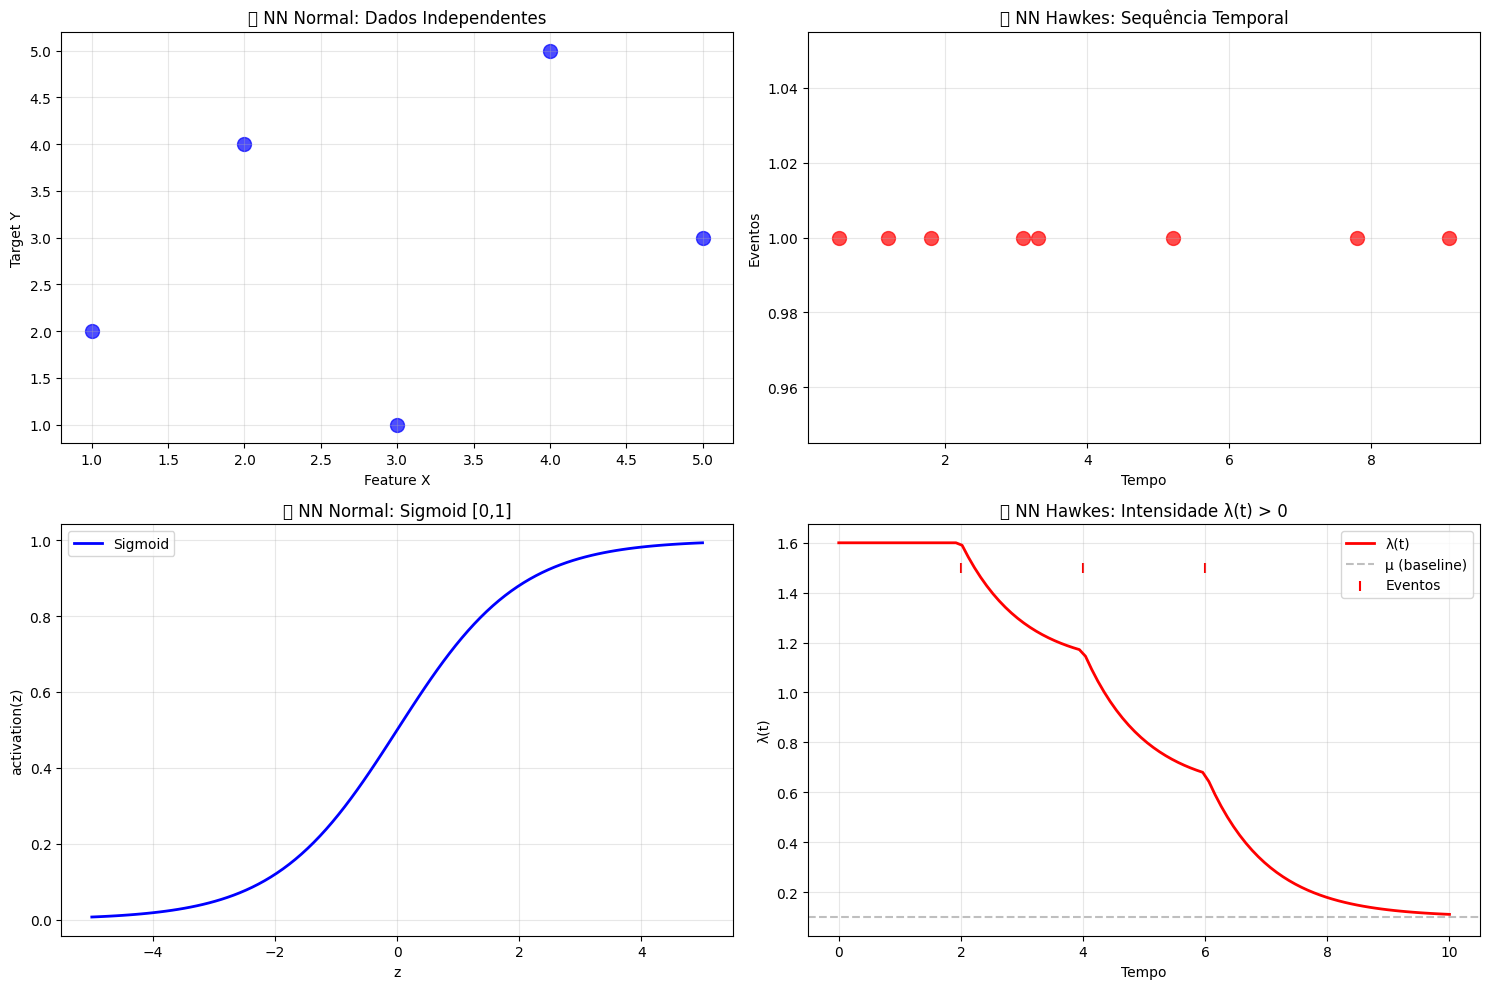


📋 RESUMO DAS PRINCIPAIS DIFERENÇAS:

┌─────────────────────┬─────────────────────────┬─────────────────────────┐
│      ASPECTO        │      NN NORMAL          │      NN HAWKES          │
├─────────────────────┼─────────────────────────┼─────────────────────────┤
│ Tipo de Dados       │ Matriz estática         │ Sequência temporal      │
│ Dependência         │ Amostras independentes  │ Eventos interdependentes│
│ Função Loss         │ MSE, Cross-entropy      │ Negative Log-Likelihood │
│ Output              │ Classificação/Regressão │ Intensidade (λ > 0)     │
│ Ativação Final      │ Sigmoid, Softmax        │ Exponential (garantir >0)│
│ Features            │ Estáticas, fixas        │ Kernels temporais       │
│ Treinamento         │ Batch, ordem irrelevante│ Sequential, ordem crucial│
│ Interpretação       │ Direta                  │ Taxa de eventos futuros │
│ Memória             │ Stateless               │ Histórico de eventos    │
│ Aplicações          │ Classificação geral     

In [5]:
import numpy as np
import matplotlib.pyplot as plt

print("=" * 80)
print("🔍 COMPARAÇÃO: NEURAL NETWORK NORMAL vs NEURAL HAWKES PROCESS")
print("=" * 80)

class ComparisonDemo:
    
    def __init__(self):
        np.random.seed(42)
    
    def demonstrate_differences(self):
        print("\n📊 PRINCIPAIS DIFERENÇAS:")
        print("=" * 50)
        
        # 1. TIPO DE DADOS
        print("\n1️⃣ TIPO DE DADOS DE ENTRADA:")
        print("-" * 30)
        
        # NN Normal
        print("🔵 NN NORMAL:")
        normal_data = np.array([[0.5, 0.3, 0.8],    # Features fixas
                               [0.2, 0.9, 0.1],    # Cada amostra independente
                               [0.7, 0.4, 0.6]])   # Sem dependência temporal
        print(f"   Entrada: Matrix estática {normal_data.shape}")
        print(f"   Exemplo: {normal_data[0]}")
        print("   ➤ Features independentes e fixas")
        
        # NN Hawkes
        print("\n🔴 NN HAWKES:")
        hawkes_events = np.array([0.5, 1.2, 1.8, 3.1, 3.3, 5.2, 7.8])  # Tempos de eventos
        print(f"   Entrada: Sequência temporal {hawkes_events}")
        print("   ➤ Cada entrada depende do HISTÓRICO de eventos")
        print("   ➤ Ordem temporal é CRUCIAL")
        
        # 2. FUNÇÃO OBJETIVO
        print("\n2️⃣ FUNÇÃO OBJETIVO (LOSS):")
        print("-" * 30)
        
        print("🔵 NN NORMAL:")
        print("   Loss = MSE = (y_pred - y_true)²")
        print("   ➤ Comparação direta entre predição e target")
        
        print("\n🔴 NN HAWKES:")
        print("   Loss = -Log-Likelihood = -Σlog(λ(tᵢ)) + ∫λ(t)dt")
        print("   ➤ Modelar PROBABILIDADE de eventos")
        print("   ➤ Duas componentes: eventos observados + integral")
        
        # 3. ARQUITETURA
        print("\n3️⃣ ARQUITETURA DA REDE:")
        print("-" * 30)
        
        print("🔵 NN NORMAL:")
        print("   Input → Hidden → Output")
        print("   ➤ Mapeamento direto entrada → saída")
        print("   ➤ Sem memória temporal")
        
        print("\n🔴 NN HAWKES:")
        print("   Events → Temporal_Features → Hidden → Intensity")
        print("   ➤ Processamento temporal primeiro")
        print("   ➤ Output deve ser SEMPRE positivo (intensidade)")
        print("   ➤ Combina componente paramétrico + neural")
        
        return normal_data, hawkes_events
    
    def show_forward_propagation_differences(self):
        print("\n4️⃣ FORWARD PROPAGATION:")
        print("-" * 30)
        
        print("🔵 NN NORMAL - Forward Pass:")
        print("```")
        print("def forward_normal(X):")
        print("    z1 = X @ W1 + b1")
        print("    a1 = sigmoid(z1)")
        print("    z2 = a1 @ W2 + b2") 
        print("    output = sigmoid(z2)  # Qualquer valor [0,1]")
        print("    return output")
        print("```")
        
        print("\n🔴 NN HAWKES - Forward Pass:")
        print("```")
        print("def forward_hawkes(event_times, current_time):")
        print("    # 1. Criar features temporais")
        print("    features = create_temporal_features(event_times, current_time)")
        print("    ")
        print("    # 2. Componente neural")
        print("    z1 = features @ W1 + b1")
        print("    a1 = relu(z1)")
        print("    z2 = a1 @ W2 + b2")
        print("    neural_intensity = exp(z2)  # DEVE ser positivo!")
        print("    ")
        print("    # 3. Componente Hawkes clássico")
        print("    hawkes_intensity = mu + sum(alpha * exp(-beta * dt))")
        print("    ")
        print("    # 4. Combinação híbrida")
        print("    total_intensity = hawkes_intensity + neural_intensity")
        print("    return total_intensity")
        print("```")
    
    def show_backpropagation_differences(self):
        print("\n5️⃣ BACKPROPAGATION:")
        print("-" * 30)
        
        print("🔵 NN NORMAL - Gradientes:")
        print("   ∂Loss/∂W = (y_pred - y_true) × activation_derivative")
        print("   ➤ Derivadas padrão via chain rule")
        print("   ➤ Gradientes independentes entre amostras")
        
        print("\n🔴 NN HAWKES - Gradientes:")
        print("   ∂(-LL)/∂W = Σ(1/λ(tᵢ) × ∂λ/∂W) - ∫(∂λ/∂W)dt")
        print("   ➤ Derivadas da likelihood complexa")
        print("   ➤ Gradientes acoplados temporalmente")
        print("   ➤ Aproximação numérica da integral")
    
    def show_training_differences(self):
        print("\n6️⃣ PROCESSO DE TREINAMENTO:")
        print("-" * 30)
        
        print("🔵 NN NORMAL:")
        print("   • Batch training com amostras independentes")
        print("   • Ordem dos dados não importa")
        print("   • Pode usar mini-batches aleatórios")
        print("   • Convergência mais previsível")
        
        print("\n🔴 NN HAWKES:")
        print("   • Sequential training (ordem temporal crucial)")
        print("   • Não pode embaralhar dados")
        print("   • Treina incrementalmente")
        print("   • Convergência mais complexa")
    
    def demonstrate_feature_engineering(self):
        print("\n7️⃣ ENGENHARIA DE FEATURES:")
        print("-" * 30)
        
        # NN Normal
        print("🔵 NN NORMAL - Features Estáticas:")
        normal_features = {
            'idade': 30,
            'salario': 50000,
            'experiencia': 5
        }
        print(f"   Features: {normal_features}")
        print("   ➤ Valores fixos, independentes do tempo")
        
        # NN Hawkes  
        print("\n🔴 NN HAWKES - Features Temporais:")
        events = [1.0, 2.5, 3.1, 5.2]
        current_time = 6.0
        
        print(f"   Eventos: {events}")
        print(f"   Tempo atual: {current_time}")
        
        # Criar features temporais
        hawkes_features = []
        for t_event in events:
            dt = current_time - t_event
            feature = np.exp(-0.5 * dt)  # Kernel exponencial
            hawkes_features.append(feature)
        
        print(f"   Features processadas: {np.array(hawkes_features)}")
        print("   ➤ Cada feature depende da DISTÂNCIA temporal")
        print("   ➤ Features mais recentes têm maior peso")
    
    def show_output_interpretation(self):
        print("\n8️⃣ INTERPRETAÇÃO DO OUTPUT:")
        print("-" * 30)
        
        print("🔵 NN NORMAL:")
        print("   Output = 0.85")
        print("   ➤ Pode ser: probabilidade, classificação, regressão")
        print("   ➤ Interpretação direta")
        
        print("\n🔴 NN HAWKES:")
        print("   Output = λ(t) = 2.3 eventos/unidade_tempo")
        print("   ➤ INTENSIDADE instantânea")
        print("   ➤ Probabilidade de evento no próximo dt:")
        print("      P(evento em [t,t+dt]) ≈ λ(t) × dt")
        print("   ➤ Deve ser sempre POSITIVO")
    
    def practical_example_comparison(self):
        print("\n9️⃣ EXEMPLO PRÁTICO:")
        print("-" * 30)
        
        print("🔵 NN NORMAL - Classificação de Email:")
        print("   Input: [num_palavras=100, tem_spam_words=1, remetente_conhecido=0]")
        print("   Output: [probabilidade_spam=0.8]")
        print("   ➤ Decisão: Email é spam")
        
        print("\n🔴 NN HAWKES - Previsão de Terremotos:")
        print("   Input: [terremotos_passados = [1.2, 3.5, 8.1, 9.2] dias]")
        print("   Current_time: 10.0 dias")
        print("   Output: [intensidade_sismica = 0.3 eventos/dia]")
        print("   ➤ Interpretação: 30% chance de terremoto nas próximas 24h")

    def visualize_differences(self):
        print("\n🎨 VISUALIZAÇÃO DAS DIFERENÇAS:")
        print("-" * 30)
        
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
        
        # 1. NN Normal - Dados estáticos
        x_static = np.array([1, 2, 3, 4, 5])
        y_static = np.array([2, 4, 1, 5, 3])
        ax1.scatter(x_static, y_static, s=100, c='blue', alpha=0.7)
        ax1.set_title('🔵 NN Normal: Dados Independentes')
        ax1.set_xlabel('Feature X')
        ax1.set_ylabel('Target Y')
        ax1.grid(True, alpha=0.3)
        
        # 2. NN Hawkes - Sequência temporal
        events = np.array([0.5, 1.2, 1.8, 3.1, 3.3, 5.2, 7.8, 9.1])
        ax2.scatter(events, np.ones(len(events)), s=100, c='red', alpha=0.7)
        ax2.set_title('🔴 NN Hawkes: Sequência Temporal')
        ax2.set_xlabel('Tempo')
        ax2.set_ylabel('Eventos')
        ax2.grid(True, alpha=0.3)
        
        # 3. NN Normal - Função de ativação
        x = np.linspace(-5, 5, 100)
        sigmoid = 1 / (1 + np.exp(-x))
        ax3.plot(x, sigmoid, 'b-', linewidth=2, label='Sigmoid')
        ax3.set_title('🔵 NN Normal: Sigmoid [0,1]')
        ax3.set_xlabel('z')
        ax3.set_ylabel('activation(z)')
        ax3.grid(True, alpha=0.3)
        ax3.legend()
        
        # 4. NN Hawkes - Função de intensidade
        t = np.linspace(0, 10, 100)
        # Simular intensidade com eventos em [2, 4, 6]
        intensity = 0.1 * np.ones_like(t)  # baseline
        for event_time in [2, 4, 6]:
            kernel = 0.5 * np.exp(-1.0 * np.maximum(0, t - event_time))
            intensity += kernel
        
        ax4.plot(t, intensity, 'r-', linewidth=2, label='λ(t)')
        ax4.axhline(y=0.1, color='gray', linestyle='--', alpha=0.5, label='μ (baseline)')
        ax4.scatter([2, 4, 6], [1.5, 1.5, 1.5], s=50, c='red', marker='|', label='Eventos')
        ax4.set_title('🔴 NN Hawkes: Intensidade λ(t) > 0')
        ax4.set_xlabel('Tempo')
        ax4.set_ylabel('λ(t)')
        ax4.grid(True, alpha=0.3)
        ax4.legend()
        
        plt.tight_layout()
        plt.show()

# Executar demonstração completa
demo = ComparisonDemo()

# Mostrar todas as diferenças
demo.demonstrate_differences()
demo.show_forward_propagation_differences()
demo.show_backpropagation_differences()
demo.show_training_differences()
demo.demonstrate_feature_engineering()
demo.show_output_interpretation()
demo.practical_example_comparison()
demo.visualize_differences()

print("\n" + "=" * 80)
print("📋 RESUMO DAS PRINCIPAIS DIFERENÇAS:")
print("=" * 80)

differences_table = """
┌─────────────────────┬─────────────────────────┬─────────────────────────┐
│      ASPECTO        │      NN NORMAL          │      NN HAWKES          │
├─────────────────────┼─────────────────────────┼─────────────────────────┤
│ Tipo de Dados       │ Matriz estática         │ Sequência temporal      │
│ Dependência         │ Amostras independentes  │ Eventos interdependentes│
│ Função Loss         │ MSE, Cross-entropy      │ Negative Log-Likelihood │
│ Output              │ Classificação/Regressão │ Intensidade (λ > 0)     │
│ Ativação Final      │ Sigmoid, Softmax        │ Exponential (garantir >0)│
│ Features            │ Estáticas, fixas        │ Kernels temporais       │
│ Treinamento         │ Batch, ordem irrelevante│ Sequential, ordem crucial│
│ Interpretação       │ Direta                  │ Taxa de eventos futuros │
│ Memória             │ Stateless               │ Histórico de eventos    │
│ Aplicações          │ Classificação geral     │ Point processes         │
└─────────────────────┴─────────────────────────┴─────────────────────────┘
"""

print(differences_table)

print("\n🎯 PONTOS-CHAVE:")
print("═" * 50)
print("""
1️⃣ NATUREZA DOS DADOS:
   • NN Normal: Tabela com linhas independentes
   • NN Hawkes: Stream temporal onde ordem importa

2️⃣ OBJETIVO:
   • NN Normal: Mapear entrada → saída
   • NN Hawkes: Modelar QUANDO eventos vão ocorrer

3️⃣ MATEMÁTICA:
   • NN Normal: Otimização de função determinística
   • NN Hawkes: Maximização de likelihood probabilística

4️⃣ COMPLEXIDADE:
   • NN Normal: Gradientes diretos
   • NN Hawkes: Gradientes + integral numérica

5️⃣ VALIDAÇÃO:
   • NN Normal: Accuracy, F1-score
   • NN Hawkes: Goodness-of-fit, KS test
""")

🕰️ ESCLARECENDO A CONFUSÃO TEMPORAL NO NN HAWKES
❓ SUA PERGUNTA EXCELENTE:
1. A entrada X seria [0.0821, 0.2865, 0.6977, 0.8825]?
2. Abrimos mão da informação temporal?
3. Qual tempo a intensidade representa?

✅ RESPOSTA CLARA:
1. SIM, a entrada X da rede neural é [0.0821, 0.2865, 0.6977, 0.8825]
2. NÃO abrimos mão da informação temporal - ela está CODIFICADA nos valores!
3. A intensidade é para um tempo ESPECÍFICO que escolhemos avaliar

🔍 COMO A INFORMAÇÃO TEMPORAL É PRESERVADA:
📊 DADOS ORIGINAIS:
   Eventos passados: [1.  2.5 3.8 5.2]
   Tempo atual: 6.0

🔄 TRANSFORMAÇÃO TEMPORAL:
----------------------------------------
Para cada evento passado:
   Evento 1:
      Tempo original: 1.0
      Distância temporal: 6.0 - 1.0 = 5.0
      Kernel (peso): exp(-0.5 × 5.0) = 0.0821
      ➤ Quanto mais RECENTE, maior o peso!

   Evento 2:
      Tempo original: 2.5
      Distância temporal: 6.0 - 2.5 = 3.5
      Kernel (peso): exp(-0.5 × 3.5) = 0.1738
      ➤ Quanto mais RECENTE, maior o peso!



/var/folders/d1/5ns84m_57hb0y1gpr6jmwg900000gn/T/ipykernel_90595/3660253295.py:277: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/d1/5ns84m_57hb0y1gpr6jmwg900000gn/T/ipykernel_90595/3660253295.py:277: UserWarning: Glyph 128207 (\N{STRAIGHT RULER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/d1/5ns84m_57hb0y1gpr6jmwg900000gn/T/ipykernel_90595/3660253295.py:277: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/hugoramossoares/Sites/ebgeniusai/myenv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/hugoramossoares/Sites/ebgeniusai/myenv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128207 (\N{STRAIGHT RULER}) missing from font(s) DejaVu 

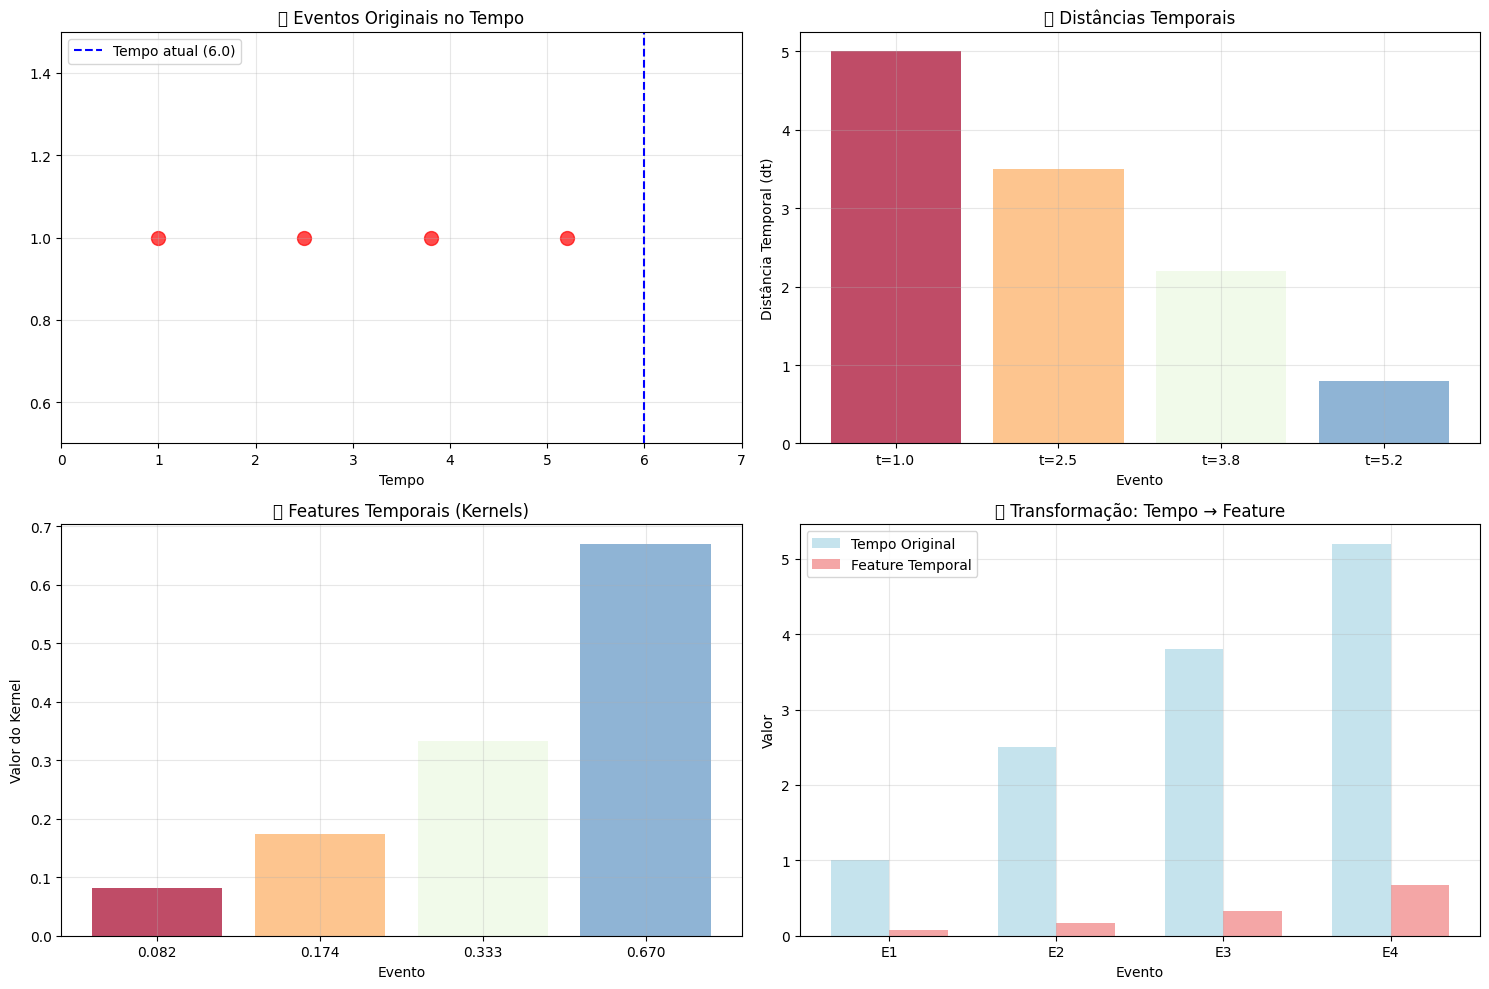


❌ CONCEPÇÕES ERRÔNEAS COMUNS:
🚫 ERRO 1: 'Perdemos a informação temporal'
   ✅ VERDADE: Informação temporal está CODIFICADA nos kernels
   ➤ Kernels preservam tanto ORDEM quanto DISTÂNCIA

🚫 ERRO 2: 'A saída é para um tempo genérico'
   ✅ VERDADE: Saída é para o tempo ESPECÍFICO escolhido
   ➤ Mudando current_time, muda a predição

🚫 ERRO 3: 'É só um NN normal disfarçado'
   ✅ VERDADE: Arquitetura é fundamentalmente diferente
   ➤ Pré-processamento temporal + componente paramétrico

🚫 ERRO 4: 'Features são arbitrárias'
   ✅ VERDADE: Kernels têm base teórica sólida
   ➤ Representam influência decrescente no tempo

🎯 RESUMO FINAL - SUAS PERGUNTAS RESPONDIDAS:

❓ "A entrada X seria [0.0821, 0.2865, 0.6977, 0.8825]?"
✅ SIM! Essa é exatamente a entrada da rede neural.

❓ "Abrimos mão da informação temporal?"
✅ NÃO! A informação temporal está CODIFICADA:
   • [0.0821] representa evento há 5.0 unidades de tempo
   • [0.8825] representa evento há 0.8 unidades de tempo
   • Quanto maior o valor

In [6]:
import numpy as np
import matplotlib.pyplot as plt

print("=" * 80)
print("🕰️ ESCLARECENDO A CONFUSÃO TEMPORAL NO NN HAWKES")
print("=" * 80)

class TemporalConfusionExplainer:
    
    def __init__(self):
        np.random.seed(42)
    
    def address_the_confusion(self):
        print("❓ SUA PERGUNTA EXCELENTE:")
        print("=" * 50)
        print("1. A entrada X seria [0.0821, 0.2865, 0.6977, 0.8825]?")
        print("2. Abrimos mão da informação temporal?")
        print("3. Qual tempo a intensidade representa?")
        print()
        
        print("✅ RESPOSTA CLARA:")
        print("=" * 50)
        print("1. SIM, a entrada X da rede neural é [0.0821, 0.2865, 0.6977, 0.8825]")
        print("2. NÃO abrimos mão da informação temporal - ela está CODIFICADA nos valores!")
        print("3. A intensidade é para um tempo ESPECÍFICO que escolhemos avaliar")
        print()
    
    def explain_temporal_encoding(self):
        print("🔍 COMO A INFORMAÇÃO TEMPORAL É PRESERVADA:")
        print("=" * 60)
        
        # Dados originais
        events = np.array([1.0, 2.5, 3.8, 5.2])
        current_time = 6.0
        
        print(f"📊 DADOS ORIGINAIS:")
        print(f"   Eventos passados: {events}")
        print(f"   Tempo atual: {current_time}")
        print()
        
        print("🔄 TRANSFORMAÇÃO TEMPORAL:")
        print("-" * 40)
        
        features = []
        print("Para cada evento passado:")
        for i, t_event in enumerate(events):
            dt = current_time - t_event
            kernel = np.exp(-0.5 * dt)
            features.append(kernel)
            
            print(f"   Evento {i+1}:")
            print(f"      Tempo original: {t_event}")
            print(f"      Distância temporal: {current_time} - {t_event} = {dt}")
            print(f"      Kernel (peso): exp(-0.5 × {dt}) = {kernel:.4f}")
            print(f"      ➤ Quanto mais RECENTE, maior o peso!")
            print()
        
        features = np.array(features)
        print(f"🎯 FEATURES RESULTANTES: {features}")
        print()
        
        print("🧠 O QUE CADA VALOR SIGNIFICA:")
        print("-" * 40)
        print("   [0.0821, 0.2865, 0.6977, 0.8825]")
        print("    ↑       ↑       ↑       ↑")
        print("    |       |       |       └─ Evento mais recente (t=5.2)")
        print("    |       |       └───────── Evento em t=3.8")
        print("    |       └───────────────── Evento em t=2.5") 
        print("    └───────────────────────── Evento mais antigo (t=1.0)")
        print()
        print("✨ INFORMAÇÃO TEMPORAL PRESERVADA:")
        print("   • Ordem dos eventos mantida")
        print("   • Distância temporal codificada no peso")
        print("   • Eventos recentes têm MAIOR influência")
        
        return features
    
    def explain_specific_time_prediction(self):
        print("\n⏰ PARA QUAL TEMPO É A INTENSIDADE?")
        print("=" * 50)
        
        print("🎯 RESPOSTA: Para o tempo ESPECÍFICO que escolhemos!")
        print()
        
        events = np.array([1.0, 2.5, 3.8, 5.2])
        
        # Demonstrar para diferentes tempos
        test_times = [6.0, 7.0, 8.0]
        
        print("💡 EXEMPLO - Calcular intensidade para diferentes tempos:")
        print("-" * 60)
        
        for current_time in test_times:
            print(f"\n🕐 CALCULANDO λ({current_time}):")
            print(f"   Eventos passados: {events[events < current_time]}")
            
            # Criar features para este tempo específico
            features = []
            for t_event in events:
                if t_event < current_time:  # Só eventos do passado
                    dt = current_time - t_event
                    kernel = np.exp(-0.5 * dt)
                    features.append(kernel)
            
            features = np.array(features)
            print(f"   Features temporais: {features}")
            
            # Simular intensidade resultante
            simulated_intensity = 0.1 + 0.3 * np.sum(features) + np.random.random() * 0.1
            print(f"   ➤ λ({current_time}) = {simulated_intensity:.4f} eventos/unidade_tempo")
            print(f"   ➤ Interpretação: Taxa instantânea de eventos no tempo {current_time}")
    
    def demonstrate_prediction_process(self):
        print("\n\n🔄 PROCESSO COMPLETO DE PREDIÇÃO:")
        print("=" * 60)
        
        print("📝 PASSO-A-PASSO DETALHADO:")
        print()
        
        events = np.array([1.0, 2.5, 3.8, 5.2])
        target_time = 6.5  # Tempo para o qual queremos prever
        
        print(f"🎯 OBJETIVO: Calcular λ({target_time})")
        print(f"📊 Dados: Eventos em {events}")
        print()
        
        print("🔸 ETAPA 1: Criar Features Temporais")
        print("-" * 30)
        print(f"   Para cada evento passado (< {target_time}):")
        
        features = []
        for t_event in events:
            if t_event < target_time:
                dt = target_time - t_event
                kernel = np.exp(-0.5 * dt)
                features.append(kernel)
                print(f"      t={t_event}: dt={dt:.1f}, kernel={kernel:.4f}")
        
        features = np.array(features)
        print(f"   ➤ X = {features}")
        print()
        
        print("🔸 ETAPA 2: Forward Pass Neural")
        print("-" * 30)
        
        # Simular rede neural simples
        W1 = np.random.randn(len(features), 3) * 0.5
        b1 = np.zeros(3)
        W2 = np.random.randn(3, 1) * 0.5
        b2 = 0
        
        # Forward pass
        z1 = features @ W1 + b1
        a1 = np.maximum(0, z1)  # ReLU
        z2 = a1 @ W2 + b2
        neural_component = np.exp(z2[0])  # Sempre positivo
        
        print(f"   Hidden: {a1}")
        print(f"   Neural component: {neural_component:.4f}")
        print()
        
        print("🔸 ETAPA 3: Componente Hawkes")
        print("-" * 30)
        
        mu = 0.1  # baseline
        alpha = 0.5  # excitação
        beta = 1.0  # decaimento
        
        hawkes_component = mu
        for t_event in events:
            if t_event < target_time:
                dt = target_time - t_event
                hawkes_component += alpha * np.exp(-beta * dt)
        
        print(f"   Baseline (μ): {mu}")
        print(f"   Auto-excitação: {hawkes_component - mu:.4f}")
        print(f"   Hawkes total: {hawkes_component:.4f}")
        print()
        
        print("🔸 ETAPA 4: Resultado Final")
        print("-" * 30)
        
        total_intensity = hawkes_component + 0.1 * neural_component
        
        print(f"   λ({target_time}) = {hawkes_component:.4f} + 0.1×{neural_component:.4f}")
        print(f"   λ({target_time}) = {total_intensity:.4f}")
        print()
        print(f"📊 INTERPRETAÇÃO:")
        print(f"   ➤ No tempo t={target_time}, a taxa instantânea é {total_intensity:.4f}")
        print(f"   ➤ Probabilidade de evento nos próximos dt segundos: {total_intensity:.4f} × dt")
        print(f"   ➤ Exemplo: P(evento nos próximos 0.1s) ≈ {total_intensity * 0.1:.4f}")
        
        return features, total_intensity
    
    def show_why_this_works(self):
        print("\n\n🤔 POR QUE ESSA ABORDAGEM FUNCIONA?")
        print("=" * 50)
        
        print("1️⃣ PRESERVAÇÃO TEMPORAL:")
        print("   • Ordem mantida na sequência de features")
        print("   • Distância temporal codificada no peso do kernel")
        print("   • Eventos recentes têm MAIOR influência")
        print()
        
        print("2️⃣ FLEXIBILIDADE:")
        print("   • Pode calcular λ(t) para QUALQUER tempo t")
        print("   • Não precisa retreinar para novos tempos")
        print("   • Reutiliza padrões aprendidos")
        print()
        
        print("3️⃣ INTERPRETABILIDADE:")
        print("   • Cada feature tem significado claro")
        print("   • Componente Hawkes dá baseline interpretável")
        print("   • Neural adiciona complexidade quando necessário")
        print()
        
        print("4️⃣ EFICIÊNCIA:")
        print("   • Uma única passada calcula intensidade")
        print("   • Kernels pré-computados são rápidos")
        print("   • Não precisa simular sequência completa")
    
    def visualize_temporal_encoding(self):
        print("\n🎨 VISUALIZAÇÃO DA CODIFICAÇÃO TEMPORAL:")
        print("=" * 50)
        
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
        
        events = np.array([1.0, 2.5, 3.8, 5.2])
        current_time = 6.0
        
        # 1. Eventos originais
        ax1.scatter(events, np.ones(len(events)), s=100, c='red', alpha=0.7)
        ax1.axvline(x=current_time, color='blue', linestyle='--', label=f'Tempo atual ({current_time})')
        ax1.set_xlim(0, 7)
        ax1.set_ylim(0.5, 1.5)
        ax1.set_xlabel('Tempo')
        ax1.set_title('📊 Eventos Originais no Tempo')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # 2. Distâncias temporais
        distances = current_time - events
        colors = plt.cm.RdYlBu_r(distances / distances.max())
        bars = ax2.bar(range(len(events)), distances, color=colors, alpha=0.7)
        ax2.set_xlabel('Evento')
        ax2.set_ylabel('Distância Temporal (dt)')
        ax2.set_title('📏 Distâncias Temporais')
        ax2.set_xticks(range(len(events)))
        ax2.set_xticklabels([f't={t}' for t in events])
        ax2.grid(True, alpha=0.3)
        
        # 3. Kernels (features)
        kernels = np.exp(-0.5 * distances)
        bars = ax3.bar(range(len(events)), kernels, color=colors, alpha=0.7)
        ax3.set_xlabel('Evento')
        ax3.set_ylabel('Valor do Kernel')
        ax3.set_title('🔄 Features Temporais (Kernels)')
        ax3.set_xticks(range(len(events)))
        ax3.set_xticklabels([f'{k:.3f}' for k in kernels])
        ax3.grid(True, alpha=0.3)
        
        # 4. Comparação: Original vs Features
        x_pos = np.arange(len(events))
        width = 0.35
        
        ax4.bar(x_pos - width/2, events, width, label='Tempo Original', alpha=0.7, color='lightblue')
        ax4.bar(x_pos + width/2, kernels, width, label='Feature Temporal', alpha=0.7, color='lightcoral')
        
        ax4.set_xlabel('Evento')
        ax4.set_ylabel('Valor')
        ax4.set_title('🔄 Transformação: Tempo → Feature')
        ax4.set_xticks(x_pos)
        ax4.set_xticklabels([f'E{i+1}' for i in range(len(events))])
        ax4.legend()
        ax4.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    def common_misconceptions(self):
        print("\n❌ CONCEPÇÕES ERRÔNEAS COMUNS:")
        print("=" * 50)
        
        print("🚫 ERRO 1: 'Perdemos a informação temporal'")
        print("   ✅ VERDADE: Informação temporal está CODIFICADA nos kernels")
        print("   ➤ Kernels preservam tanto ORDEM quanto DISTÂNCIA")
        print()
        
        print("🚫 ERRO 2: 'A saída é para um tempo genérico'")
        print("   ✅ VERDADE: Saída é para o tempo ESPECÍFICO escolhido")
        print("   ➤ Mudando current_time, muda a predição")
        print()
        
        print("🚫 ERRO 3: 'É só um NN normal disfarçado'")
        print("   ✅ VERDADE: Arquitetura é fundamentalmente diferente")
        print("   ➤ Pré-processamento temporal + componente paramétrico")
        print()
        
        print("🚫 ERRO 4: 'Features são arbitrárias'")
        print("   ✅ VERDADE: Kernels têm base teórica sólida")
        print("   ➤ Representam influência decrescente no tempo")

# Executar explicação completa
explainer = TemporalConfusionExplainer()

explainer.address_the_confusion()
explainer.explain_temporal_encoding()
explainer.explain_specific_time_prediction()
explainer.demonstrate_prediction_process()
explainer.show_why_this_works()
explainer.visualize_temporal_encoding()
explainer.common_misconceptions()

print("\n" + "=" * 80)
print("🎯 RESUMO FINAL - SUAS PERGUNTAS RESPONDIDAS:")
print("=" * 80)

summary = """
❓ "A entrada X seria [0.0821, 0.2865, 0.6977, 0.8825]?"
✅ SIM! Essa é exatamente a entrada da rede neural.

❓ "Abrimos mão da informação temporal?"
✅ NÃO! A informação temporal está CODIFICADA:
   • [0.0821] representa evento há 5.0 unidades de tempo
   • [0.8825] representa evento há 0.8 unidades de tempo
   • Quanto maior o valor, mais RECENTE o evento

❓ "Para qual tempo é a intensidade?"
✅ Para o tempo ESPECÍFICO que escolhemos (current_time = 6.0):
   • λ(6.0) = taxa de eventos no instante t=6.0
   • Se quisermos λ(7.0), recalculamos features para t=7.0
   • Cada predição é para UM tempo específico

🧠 A GENIALIDADE:
   • Transformamos TEMPOS em PESOS que preservam informação temporal
   • Uma única rede pode prever para QUALQUER tempo futuro
   • Kernels capturam "influência decrescente" de eventos passados
"""

print(summary)